Some basic projections of what the Heat might expect from Giannis moving forward.

In [151]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [178]:
plt.style.use('dark_background')

In [83]:
from career_stats import get_career_stats

In [85]:
cs = get_career_stats()

In [86]:
cs.reset_index().head()

,player,vorp,per,g,mp,ows,dws
0,A.C. Green,0.90,13.35,1361,39044.0,60.7,43.5
1,A.J. Bramlett,-0.20,-0.40,8,61.0,-0.2,0.1
2,A.J. English,-0.75,11.55,151,3108.0,-0.4,1.4
3,A.J. Green,-0.05,9.95,242,4888.0,4.8,2.3
4,A.J. Guyton,0.00,10.30,80,1246.0,0.3,-0.1


In [87]:
stats_path = kagglehub.dataset_download("sumitrodatta/nba-aba-baa-stats")
advanced = pd.read_csv(stats_path + "/Advanced.csv")

how do players do at giannis' age?

In [88]:
advanced.columns

Index(['season', 'lg', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs',
       'mp', 'per', 'ts_percent', 'x3p_ar', 'f_tr', 'orb_percent',
       'drb_percent', 'trb_percent', 'ast_percent', 'stl_percent',
       'blk_percent', 'tov_percent', 'usg_percent', 'ows', 'dws', 'ws',
       'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp'],
      dtype='str')

In [89]:
advanced[advanced.player == "Bam Adebayo"]

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,tov_percent,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,73,73.0,2365.0,...,8.3,25.0,2.8,3.6,6.4,0.129,1.5,0.4,2.0,2.4
735,2025,NBA,Bam Adebayo,adebaba01,27.0,MIA,C,78,78.0,2674.0,...,11.4,23.5,3.5,4.0,7.5,0.135,1.0,1.0,2.0,2.7
1471,2024,NBA,Bam Adebayo,adebaba01,26.0,MIA,C,71,71.0,2416.0,...,12.0,24.9,2.9,4.3,7.2,0.144,0.8,1.7,2.4,2.7
2205,2023,NBA,Bam Adebayo,adebaba01,25.0,MIA,C,75,75.0,2598.0,...,12.7,25.2,3.6,3.8,7.4,0.137,0.8,0.8,1.5,2.3
2884,2022,NBA,Bam Adebayo,adebaba01,24.0,MIA,C,56,56.0,1825.0,...,14.4,25.0,3.6,3.5,7.2,0.188,1.7,2.1,3.8,2.7
3697,2021,NBA,Bam Adebayo,adebaba01,23.0,MIA,C,64,64.0,2143.0,...,15.0,23.7,5.6,3.2,8.8,0.197,2.9,2.0,4.9,3.7
4400,2020,NBA,Bam Adebayo,adebaba01,22.0,MIA,PF,72,72.0,2417.0,...,17.6,21.2,4.6,3.9,8.5,0.168,1.4,2.0,3.4,3.3
5054,2019,NBA,Bam Adebayo,adebaba01,21.0,MIA,C,82,28.0,1913.0,...,17.1,15.8,3.4,3.4,6.8,0.171,-0.4,2.2,1.8,1.8
5761,2018,NBA,Bam Adebayo,adebaba01,20.0,MIA,C,69,19.0,1368.0,...,13.6,15.9,2.3,1.9,4.2,0.148,-1.1,0.7,-0.4,0.6


In [122]:
grouped = advanced.groupby('player')['season'].max()

retired = grouped[grouped < 2025].reset_index()

In [123]:
retired_df = advanced[advanced.player.isin(retired.player)]

In [124]:
retired_df

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,tov_percent,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
1479,2024,NBA,Timmy Allen,allenti01,24.0,MEM,SF,5,0.0,125.0,...,7.7,8.9,-0.2,0.1,-0.1,-0.041,-10.3,-0.7,-11.1,-0.3
1488,2024,NBA,Ryan Arcidiacono,arcidry01,29.0,NYK,PG,20,0.0,45.0,...,25.0,7.7,-0.1,0.1,-0.1,-0.089,-11.5,1.9,-9.6,-0.1
1491,2024,NBA,Udoka Azubuike,azubuud01,24.0,PHO,C,16,0.0,113.0,...,12.2,12.6,0.1,0.1,0.2,0.100,-3.0,-0.1,-3.2,0.0
1492,2024,NBA,Ibou Badji,badjiib01,21.0,POR,C,22,1.0,226.0,...,35.5,8.0,0.0,0.2,0.2,0.046,-7.7,1.9,-5.8,-0.2
1496,2024,NBA,Amari Bailey,baileam01,19.0,CHO,PG,10,0.0,65.0,...,12.9,21.1,-0.1,0.0,-0.1,-0.044,-5.2,-3.1,-8.3,-0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33334,1947,BAA,Ray Wertis,wertira01,23.0,2TM,NaN,61,NaN,NaN,...,NaN,NaN,-1.2,0.6,-0.6,NaN,NaN,NaN,NaN,NaN
33335,1947,BAA,Ray Wertis,wertira01,23.0,TRH,NaN,18,NaN,NaN,...,NaN,NaN,-0.6,0.3,-0.3,NaN,NaN,NaN,NaN,NaN
33336,1947,BAA,Ray Wertis,wertira01,23.0,CLR,NaN,43,NaN,NaN,...,NaN,NaN,-0.6,0.3,-0.4,NaN,NaN,NaN,NaN,NaN
33337,1947,BAA,Max Zaslofsky,zasloma01,21.0,CHS,SG,61,NaN,NaN,...,NaN,NaN,7.6,2.0,9.6,NaN,NaN,NaN,NaN,NaN


In [126]:
over_32 = retired_df[retired_df.age >= 32]

In [125]:
lt_32 = retired_df[retired_df.age < 32]

In [127]:
o32_sums = over_32.groupby('player')[['ows', 'dws', 'g']].sum()
u32_sums = lt_32.groupby('player')[['ows', 'dws', 'g']].sum()


In [128]:
under_vs_over = u32_sums.merge(o32_sums, left_on='player', 
                     suffixes=('_u32', '_o32'),
                     right_on='player',
                     how='outer')

In [129]:
under_vs_over = under_vs_over.fillna(0)

In [130]:
under_vs_over.head()

,ows_u32,dws_u32,g_u32,ows_o32,dws_o32,g_o32
player,,,,,,
A.C. Green,46.8,28.6,817.0,13.9,14.9,544.0
A.J. Bramlett,-0.2,0.1,8.0,0.0,0.0,0.0
A.J. English,-0.4,1.4,151.0,0.0,0.0,0.0
A.J. Guyton,0.3,-0.1,80.0,0.0,0.0,0.0
A.J. Hammons,-0.2,0.2,22.0,0.0,0.0,0.0


In [132]:
under_vs_over['o_ratio'] = under_vs_over.ows_o32 / under_vs_over.ows_u32
under_vs_over['d_ratio'] = under_vs_over.dws_o32 / under_vs_over.dws_u32

under_vs_over['g_ratio'] = under_vs_over.g_o32 / under_vs_over.g_u32

under_vs_over['total_u_ws'] = under_vs_over.ows_u32 + under_vs_over.dws_u32
under_vs_over['total_o_ws'] = under_vs_over.ows_o32 + under_vs_over.dws_o32

under_vs_over['t_ratio'] = under_vs_over.total_o_ws / under_vs_over.total_u_ws

under_vs_over 


,ows_u32,dws_u32,g_u32,ows_o32,dws_o32,g_o32,o_ratio,d_ratio,g_ratio,total_u_ws,total_o_ws,t_ratio
player,,,,,,,,,,,,
A.C. Green,46.8,28.6,817.0,13.9,14.9,544.0,0.297009,0.520979,0.665851,75.4,28.8,0.381963
A.J. Bramlett,-0.2,0.1,8.0,0.0,0.0,0.0,-0.000000,0.000000,0.000000,-0.1,0.0,-0.000000
A.J. English,-0.4,1.4,151.0,0.0,0.0,0.0,-0.000000,0.000000,0.000000,1.0,0.0,0.000000
A.J. Guyton,0.3,-0.1,80.0,0.0,0.0,0.0,0.000000,-0.000000,0.000000,0.2,0.0,0.000000
A.J. Hammons,-0.2,0.2,22.0,0.0,0.0,0.0,-0.000000,0.000000,0.000000,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
Šarūnas Marčiulionis,15.1,5.3,346.0,-0.6,0.1,17.0,-0.039735,0.018868,0.049133,20.4,-0.5,-0.024510
Žan Tabak,-0.8,2.9,304.0,0.0,0.0,0.0,-0.000000,0.000000,0.000000,2.1,0.0,0.000000
Žarko Paspalj,-0.5,0.2,28.0,0.0,0.0,0.0,-0.000000,0.000000,0.000000,-0.3,0.0,-0.000000


In [134]:
under_vs_over.sort_values('total_o_ws', ascending=False)[:20]

,ows_u32,dws_u32,g_u32,ows_o32,dws_o32,g_o32,o_ratio,d_ratio,g_ratio,total_u_ws,total_o_ws,t_ratio
player,,,,,,,,,,,,
Karl Malone,68.2,55.2,816.0,74.1,37.4,660.0,1.086510,0.677536,0.808824,123.4,111.5,0.903566
Kareem Abdul-Jabbar,115.9,60.2,773.0,63.1,34.3,787.0,0.544435,0.569767,1.018111,176.1,97.4,0.553095
John Stockton,71.2,39.9,816.0,71.5,25.1,688.0,1.004213,0.629073,0.843137,111.1,96.6,0.869487
Robert Parish,34.1,37.8,706.0,40.0,35.1,905.0,1.173021,0.928571,1.281870,71.9,75.1,1.044506
Reggie Miller,84.7,18.5,801.0,55.7,15.5,588.0,0.657615,0.837838,0.734082,103.2,71.2,0.689922
Tim Duncan,69.2,72.2,824.0,30.8,34.2,568.0,0.445087,0.473684,0.689320,141.4,65.0,0.459689
Michael Jordan,107.9,42.1,684.0,42.0,22.1,388.0,0.389249,0.524941,0.567251,150.0,64.1,0.427333
Wilt Chamberlain,125.4,73.3,779.0,37.6,26.2,339.0,0.299841,0.357435,0.435173,198.7,63.8,0.321087
Dikembe Mutombo,23.9,37.5,553.0,27.9,35.7,718.0,1.167364,0.952000,1.298373,61.4,63.6,1.035831


In [158]:
nonzero_t  = under_vs_over[under_vs_over.t_ratio > 0]

nonzero_t = nonzero_t.replace([np.inf, -np.inf], np.nan)
nonzero_t = nonzero_t.dropna()

nonzero_t['decile_ratio'] = pd.qcut(nonzero_t.t_ratio, q=10, labels=range(1,11))

In [162]:
assert len(under_vs_over) == 4667

In [160]:
assert len(nonzero_t) == 790

In [164]:
nonzero_t[nonzero_t.decile_ratio > 8]

,ows_u32,dws_u32,g_u32,ows_o32,dws_o32,g_o32,o_ratio,d_ratio,g_ratio,total_u_ws,total_o_ws,t_ratio,decile_ratio
player,,,,,,,,,,,,,
A.C. Green,46.8,28.6,817.0,13.9,14.9,544.0,0.297009,0.520979,0.665851,75.4,28.8,0.381963,9
Alan Anderson,1.9,2.3,213.0,1.9,1.4,117.0,1.000000,0.608696,0.549296,4.2,3.3,0.785714,10
Alex English,52.7,15.2,787.0,28.1,9.8,484.0,0.533207,0.644737,0.614994,67.9,37.9,0.558174,10
Andre Miller,48.3,21.7,813.0,27.9,13.8,749.0,0.577640,0.635945,0.921279,70.0,41.7,0.595714,10
Antawn Jamison,49.2,14.8,717.0,18.9,11.0,432.0,0.384146,0.743243,0.602510,64.0,29.9,0.467187,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vlade Divac,31.3,38.1,797.0,12.3,14.7,337.0,0.392971,0.385827,0.422836,69.4,27.0,0.389049,9
Walt Simon,6.9,7.7,311.0,5.2,7.6,230.0,0.753623,0.987013,0.739550,14.6,12.8,0.876712,10
Walter Davis,35.5,21.2,619.0,15.3,6.7,485.0,0.430986,0.316038,0.783522,56.7,22.0,0.388007,9


t_ratio, which is ratio of total win shares after 31 versus before 31.

a lot of players retire in their early 30's. not surprising >90% of players have less than half their win shares after age 31.

In [166]:
nonzero_t.groupby("decile_ratio")["t_ratio"].mean()

decile_ratio
1     0.008913
2     0.026032
3     0.050583
4     0.078310
5     0.119747
6     0.169730
7     0.234769
8     0.315111
9     0.443954
10    0.934896
Name: t_ratio, dtype: float64

what about truly elite players? giannis has had 125 win shares in his life so far. 

In [212]:
giannis_caliber = nonzero_t[nonzero_t.total_u_ws > 100].reset_index().copy()

need to recalculate deciles on the subset

In [213]:
giannis_caliber.head()


,player,ows_u32,dws_u32,g_u32,ows_o32,dws_o32,g_o32,o_ratio,d_ratio,g_ratio,total_u_ws,total_o_ws,t_ratio,decile_ratio
0,Adrian Dantley,105.7,20.5,837.0,20.8,6.6,270.0,0.196783,0.321951,0.322581,126.2,27.4,0.217116,7
1,Artis Gilmore,78.7,57.9,796.0,35.3,18.6,604.0,0.448539,0.321244,0.758794,136.6,53.9,0.394583,9
2,Bill Russell,25.5,106.7,727.0,4.4,26.9,236.0,0.172549,0.252109,0.324622,132.2,31.3,0.236762,7
3,Bob Lanier,69.3,32.8,770.0,11.1,11.2,252.0,0.160173,0.341463,0.327273,102.1,22.3,0.218413,7
4,Bob Pettit,87.4,41.7,742.0,4.3,2.7,50.0,0.049199,0.064748,0.067385,129.1,7.0,0.054222,3


In [214]:
giannis_caliber['decile_ratio'] = pd.qcut(giannis_caliber.t_ratio, q=10, labels=range(1,11))

In [215]:
giannis_caliber.groupby("decile_ratio")["t_ratio"].mean()

decile_ratio
1     0.047038
2     0.151730
3     0.189247
4     0.227434
5     0.262333
6     0.303592
7     0.347178
8     0.423179
9     0.492268
10    0.754017
Name: t_ratio, dtype: float64

mean win shares by decile for these elite players.

In [190]:
giannis_caliber.groupby("decile_ratio")["total_o_ws"].median()

decile_ratio
1      7.00
2     21.50
3     24.45
4     31.20
5     37.20
6     40.65
7     53.10
8     48.00
9     59.00
10    97.40
Name: total_o_ws, dtype: float64

so the mean outcome is about 35 total win shares from giannis for the rest of his career.

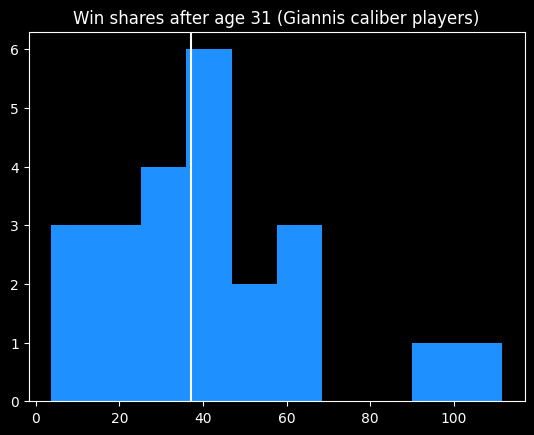

In [191]:
plt.hist(giannis_caliber.total_o_ws, color='dodgerblue')
plt.title('Win shares after age 31 (Giannis caliber players)')
plt.axvline(37.2)

what about a 90% percentile interval

In [216]:
low, high = np.percentile(giannis_caliber.total_o_ws, [25, 75])
print(f"IQR: {low:.1f} – {high:.1f} win shares")

IQR: 22.4 – 53.6 win shares


there are actually only 23 players with > 120 WS before age 32. There are 37 with > 100 WS

In [217]:
giannis_caliber

,player,ows_u32,dws_u32,g_u32,ows_o32,dws_o32,g_o32,o_ratio,d_ratio,g_ratio,total_u_ws,total_o_ws,t_ratio,decile_ratio
0,Adrian Dantley,105.7,20.5,837.0,20.8,6.6,270.0,0.196783,0.321951,0.322581,126.2,27.4,0.217116,3
1,Artis Gilmore,78.7,57.9,796.0,35.3,18.6,604.0,0.448539,0.321244,0.758794,136.6,53.9,0.394583,8
2,Bill Russell,25.5,106.7,727.0,4.4,26.9,236.0,0.172549,0.252109,0.324622,132.2,31.3,0.236762,4
3,Bob Lanier,69.3,32.8,770.0,11.1,11.2,252.0,0.160173,0.341463,0.327273,102.1,22.3,0.218413,4
4,Bob Pettit,87.4,41.7,742.0,4.3,2.7,50.0,0.049199,0.064748,0.067385,129.1,7.0,0.054222,1
5,Carmelo Anthony,67.4,32.9,979.0,8.8,7.3,358.0,0.130564,0.221884,0.365679,100.3,16.1,0.160518,2
6,Charles Barkley,98.5,41.7,819.0,24.9,12.3,254.0,0.252792,0.294964,0.310134,140.2,37.2,0.265335,5
7,Clyde Drexler,63.9,38.4,826.0,29.9,15.3,336.0,0.467919,0.398438,0.406780,102.3,45.2,0.441838,9
8,Dan Issel,78.7,39.9,824.0,32.2,6.9,394.0,0.409149,0.172932,0.478155,118.6,39.1,0.329680,7
9,David Robinson,66.6,48.9,563.0,31.9,31.2,424.0,0.478979,0.638037,0.753108,115.5,63.1,0.546320,9


In [199]:
retired_df.head()

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,tov_percent,usg_percent,ows,dws,ws,ws_48,obpm,dbpm,bpm,vorp
1479,2024,NBA,Timmy Allen,allenti01,24.0,MEM,SF,5,0.0,125.0,...,7.7,8.9,-0.2,0.1,-0.1,-0.041,-10.3,-0.7,-11.1,-0.3
1488,2024,NBA,Ryan Arcidiacono,arcidry01,29.0,NYK,PG,20,0.0,45.0,...,25.0,7.7,-0.1,0.1,-0.1,-0.089,-11.5,1.9,-9.6,-0.1
1491,2024,NBA,Udoka Azubuike,azubuud01,24.0,PHO,C,16,0.0,113.0,...,12.2,12.6,0.1,0.1,0.2,0.100,-3.0,-0.1,-3.2,0.0
1492,2024,NBA,Ibou Badji,badjiib01,21.0,POR,C,22,1.0,226.0,...,35.5,8.0,0.0,0.2,0.2,0.046,-7.7,1.9,-5.8,-0.2
1496,2024,NBA,Amari Bailey,baileam01,19.0,CHO,PG,10,0.0,65.0,...,12.9,21.1,-0.1,0.0,-0.1,-0.044,-5.2,-3.1,-8.3,-0.1


In [206]:
as_list = retired_df.groupby("player")['ws'].apply(list)

In [207]:
as_list

player
A.C. Green              [3.2, 5.0, 1.4, 5.2, 4.8, 0.8, 4.0, 4.4, 6.7, ...
A.J. Bramlett                                                      [-0.2]
A.J. English                                                   [0.9, 0.2]
A.J. Guyton                                              [-0.1, 0.1, 0.3]
A.J. Hammons                                                        [0.0]
                                              ...                        
Šarūnas Marčiulionis                 [-0.5, 2.6, 2.3, 3.0, 6.4, 2.5, 3.8]
Žan Tabak                       [0.9, 0.1, 0.0, -0.2, 0.2, 0.1, 1.1, 0.2]
Žarko Paspalj                                                      [-0.3]
Žarko Čabarkapa                                [0.3, 1.3, 0.1, 1.2, -0.4]
Željko Rebrača                        [0.7, 2.4, 0.5, 0.5, 0.0, 1.3, 3.3]
Name: ws, Length: 4682, dtype: object

In [218]:
legends = retired_df[retired_df.player.isin(giannis_caliber.player)]

In [219]:
legends_as_list = legends.groupby("player")['ws'].apply(list)
legends_as_list

player
Adrian Dantley         [0.1, 3.1, 7.4, 5.3, 2.1, 9.4, 10.3, 12.8, 8.0...
Artis Gilmore          [0.9, 0.1, 0.8, 4.9, 7.1, 10.5, 6.7, 11.0, 12....
Bill Russell           [10.9, 8.2, 12.2, 11.7, 16.9, 17.3, 13.5, 15.5...
Bob Lanier             [6.7, 2.3, 6.6, 6.8, 7.4, 4.2, 3.2, 5.9, 10.1,...
Bob Pettit             [7.1, 14.9, 14.3, 11.5, 14.9, 11.5, 14.8, 11.0...
Carmelo Anthony        [3.6, 2.6, 1.3, 0.3, 3.7, 4.7, 6.4, 2.9, 10.7,...
Charles Barkley        [1.9, 6.8, 8.6, 9.4, 10.5, 10.6, 8.8, 14.4, 12...
Clyde Drexler          [6.8, 8.1, 6.7, 11.7, 6.5, 5.2, 6.8, 6.0, 12.8...
Dan Issel              [4.3, 6.1, 8.4, 9.8, 10.5, 11.5, 9.8, 11.1, 10...
David Robinson         [6.0, 10.1, 12.1, 12.7, 8.4, 13.8, 0.7, 18.3, ...
Dirk Nowitzki          [0.3, 4.8, 2.5, 6.8, 7.2, 10.9, 5.0, 7.6, 11.1...
Dolph Schayes          [-0.1, 2.4, 3.1, 8.5, 9.5, 9.4, 13.7, 12.5, 11...
Dwight Howard          [3.5, 4.0, 5.4, 0.6, 6.8, 8.3, 6.6, 3.6, 8.0, ...
George Gervin          [3.0, 4.6, 5.5, 9.4, 

In [228]:
sample_players = legends_as_list.sample(10)

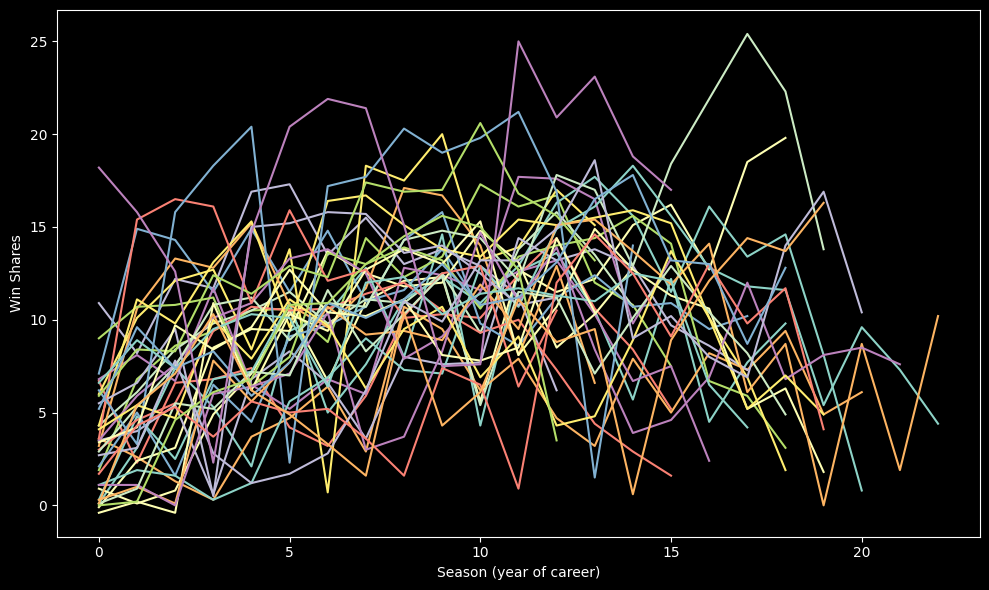

In [231]:
fig, ax = plt.subplots(figsize=(10, 6))

for player, ws_list in legends_as_list.items():
    ax.plot(range(len(ws_list)), ws_list, label=player)

ax.set_xlabel("Season (year of career)")
ax.set_ylabel("Win Shares")
#ax.legend()
plt.tight_layout()
plt.show()